In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

GITHUB_REPO = "https://github.com/danokundaye/kidney-tumour-detection.git"
REPO_NAME = "kidney-tumour-detection"
CLONE_PATH = f"/content/{REPO_NAME}"

if os.path.exists(CLONE_PATH):
    print("Repository already exists, pulling latest changes...")
    os.chdir(CLONE_PATH)
    os.system("git pull origin main")
    print("Repository updated")
else:
    print("Cloning repository...")
    os.system(f"git clone {GITHUB_REPO} {CLONE_PATH}")
    print("Repository cloned")

if CLONE_PATH not in sys.path:
    sys.path.insert(0, CLONE_PATH)
    print(f"Added {CLONE_PATH} to Python path")

print(f"\nWorking directory: {CLONE_PATH}")
print("GitHub sync complete")

Mounted at /content/drive
Cloning repository...
Repository cloned
Added /content/kidney-tumour-detection to Python path

Working directory: /content/kidney-tumour-detection
GitHub sync complete


In [3]:
import pandas as pd
from pathlib import Path

DRIVE_BASE = '/content/drive/MyDrive/kidney-tumour-detection'
results_csv = Path(DRIVE_BASE) / 'results/phase5_yolo_retrain/yolov8s_retrain_run1/results.csv'

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()  # yolo adds whitespace to column names
print('columns:')
for col in df.columns:
    print(f'  {col}')

print(f'\ntotal rows (epochs): {len(df)}')
print(f'\nlast 3 rows:')
print(df.tail(3).to_string(index=False))

columns:
  epoch
  time
  train/box_loss
  train/cls_loss
  train/dfl_loss
  metrics/precision(B)
  metrics/recall(B)
  metrics/mAP50(B)
  metrics/mAP50-95(B)
  val/box_loss
  val/cls_loss
  val/dfl_loss
  lr/pg0
  lr/pg1
  lr/pg2

total rows (epochs): 100

last 3 rows:
 epoch    time  train/box_loss  train/cls_loss  train/dfl_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss  lr/pg0  lr/pg1  lr/pg2
    98 19127.1         0.86135         0.40137          0.8182               0.56750            0.46721           0.42838              0.18737       2.50989       1.36964       1.06270 0.00004 0.00004 0.00004
    99 19322.2         0.84853         0.39544          0.8130               0.56257            0.46799           0.42534              0.18612       2.51365       1.37294       1.06654 0.00003 0.00003 0.00003
   100 19516.3         0.84286         0.39204          0.8111               0.56142            0.4695

In [8]:
# Generate yolo label files for 70 test cases
# Needed for formal yolo evaluation on held out test set
# Reuses process_case from yolo_label_generation.py
import sys
import yaml
import pandas as pd
from pathlib import Path
from tqdm import tqdm

sys.path.insert(0, '/content/kidney-tumour-detection')
from src.preprocessing.yolo_label_generation import process_case

config_path = "/content/kidney-tumour-detection/configs/config.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

slices_dir = Path(config['paths']['slices_dir'])
splits_dir = Path(config['paths']['splits_dir'])
img_size   = config['preprocessing']['slice_size']
min_area   = config['preprocessing']['min_tumor_area']

test_df    = pd.read_csv(splits_dir / 'test.csv')
test_cases = test_df['case_id'].tolist()

print(f'Generating yolo labels for {len(test_cases)} test cases\n')

stats = []
for case_id in tqdm(test_cases, desc='Generating labels...'):
    masks_dir  = slices_dir / 'test' / case_id / 'masks'
    labels_dir = slices_dir / 'test' / case_id / 'labels'

    # skip if already done
    if labels_dir.exists() and any(labels_dir.glob('*.txt')):
        continue

    result = process_case(
        case_id    = case_id,
        masks_dir  = masks_dir,
        labels_dir = labels_dir,
        img_height = img_size,
        img_width  = img_size,
        min_area   = min_area
    )
    stats.append(result)

if stats:
    df = pd.DataFrame(stats)
    print(f'\nLabels generated')
    print(f'  Cases processed  : {len(df)}')
    print(f'  Total slices     : {df["total_slices"].sum()}')
    print(f'  Positive slices  : {df["positive_slices"].sum()}')
    print(f'  Total boxes      : {df["total_boxes"].sum()}')
else:
    print('All test labels already exist')

Generating yolo labels for 70 test cases



Generating labels...: 100%|██████████| 70/70 [1:37:30<00:00, 83.58s/it]


Labels generated
  Cases processed  : 69
  Total slices     : 34980
  Positive slices  : 12830
  Total boxes      : 13594


In [2]:
!pip install ultralytics -q
!pip install segmentation-models-pytorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.9 MB/s eta 0:00:00


In [3]:
# Formal yolo evaluation on 70 held out test cases
# uses yolo val mode with generated ground truth labels
# produces map@0.5, map@0.75, precision, recall

import yaml
from pathlib import Path
from ultralytics import YOLO

config_path = "/content/kidney-tumour-detection/configs/config.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

DRIVE_BASE  = '/content/drive/MyDrive/kidney-tumour-detection'
slices_dir  = Path(config['paths']['slices_dir'])
results_dir = Path(config['paths']['results_dir'])
yolo_path   = results_dir / 'phase5_yolo_retrain/yolov8s_retrain_run1/weights/best.pt'

# build a data.yaml pointing to test images and labels
test_yaml_path = Path('/content/kidney-tumour-detection') / 'configs/yolo_test_eval.yaml'
test_yaml_path.parent.mkdir(parents = True, exist_ok = True)

# collect all test image paths
test_images = sorted((slices_dir / 'test').rglob('images/*.png'))
test_txt    = Path(DRIVE_BASE) / 'dataset/processed/splits/yolo_test_eval.txt'

with open(test_txt, 'w') as f:
    for p in test_images:
        f.write(str(p) + '\n')

print(f'Test images listed : {len(test_images)}')

# write data yaml
yaml_content = f"""
path: {slices_dir}
train: {test_txt}
val: {test_txt}
test: {test_txt}
nc: 1
names: ['kidney']
"""
with open(test_yaml_path, 'w') as f:
    f.write(yaml_content)

print(f'data yaml written  : {test_yaml_path}')

# run evaluation
model   = YOLO(str(yolo_path))
metrics = model.val(
    data    = str(test_yaml_path),
    split   = 'test',
    conf    = 0.10,
    iou     = 0.50,
    imgsz   = 512,
    verbose = True,
    save_json = False,
)

print('\nYOLO test evaluation results\n')
print(f'Precision  : {metrics.box.mp:.4f}')
print(f'Recall     : {metrics.box.mr:.4f}')
print(f'mAP@0.5    : {metrics.box.map50:.4f}')
print(f'mAP@0.5:0.95: {metrics.box.map:.4f}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Test images listed : 35492
data yaml written  : /content/kidney-tumour-detection/configs/yolo_test_eval.yaml
Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.0 ms, read: 0.0±0.0 MB/s, size: 15.2 KB)
val: Scanning /content/drive/MyDrive/kidney-tumour-detection/dataset/processed/slices/test/case_00001/labels... 34983 images, 22662 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35492/35492 7.8it/s 1:16:20
val: New cache created: /content/drive/MyDrive/kidney-tumour-detection/dataset/processed/slices/test/case_00001/labels.ca

In [4]:
# Phase 10 - evaluation and metrics
# reads from saved outputs, no retraining or rerunning

import yaml
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import seaborn as sns
import nibabel as nib
import cv2

from pathlib import Path
from PIL import Image
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

config_path = '/content/kidney-tumour-detection/configs/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)

DRIVE_BASE  = '/content/drive/MyDrive/kidney-tumour-detection'
results_dir = Path(config['paths']['results_dir'])
splits_dir  = Path(config['paths']['splits_dir'])
slices_dir  = Path(config['paths']['slices_dir'])

output_dir  = results_dir / 'phase10_evaluation'
output_dir.mkdir(parents=True, exist_ok=True)

print(f'output directory: {output_dir}')

output directory: /content/drive/MyDrive/kidney-tumour-detection/results/phase10_evaluation


In [5]:
# YOLO detection metrics
# from formal test evaluation run before phase 10

# results from formal yolo val run on 70 test cases (35492 slices)
yolo_metrics = {
    'precision'      : 0.6426,
    'recall'         : 0.5060,
    'map_50'         : 0.5340,
    'map_50_95'      : 0.2405,
    'conf_threshold' : 0.10,
    'iou_threshold'  : 0.50,
    'test_images'    : 35492,
    'test_instances' : 13594,
}

# case level detection from phase 9 pipeline
pred_df  = pd.read_csv(results_dir / 'phase9_pipeline/predictions.csv')
test_df  = pd.read_csv(splits_dir  / 'test.csv')

case_det = (pred_df['n_detected'] > 0).sum()
yolo_metrics['case_level_detection_rate'] = round(case_det / len(pred_df), 4)
yolo_metrics['cases_with_detection']      = int(case_det)
yolo_metrics['total_test_cases']          = len(pred_df)

print('YOLO detection metrics (test set)\n')
for k, v in yolo_metrics.items():
    print(f'  {k:<35}: {v}')

# save
yolo_df = pd.DataFrame([yolo_metrics])
yolo_df.to_csv(output_dir / 'yolo_metrics.csv', index=False)
print(f'\nSaved: yolo_metrics.csv')

YOLO detection metrics (test set)

  precision                          : 0.6426
  recall                             : 0.506
  map_50                             : 0.534
  map_50_95                          : 0.2405
  conf_threshold                     : 0.1
  iou_threshold                      : 0.5
  test_images                        : 35492
  test_instances                     : 13594
  case_level_detection_rate          : 0.9714
  cases_with_detection               : 68
  total_test_cases                   : 70

Saved: yolo_metrics.csv


In [6]:
# U-Net segmentation metrics from phase 9 predictions.csv

dice_vals = pred_df['dice_3d']
iou_vals  = pred_df['iou_3d']

seg_metrics = {
    'mean_dice'  : round(dice_vals.mean(), 4),
    'median_dice': round(dice_vals.median(), 4),
    'std_dice'   : round(dice_vals.std(), 4),
    'max_dice'   : round(dice_vals.max(), 4),
    'min_dice'   : round(dice_vals.min(), 4),
    'mean_iou'   : round(iou_vals.mean(), 4),
    'median_iou' : round(iou_vals.median(), 4),
    'std_iou'    : round(iou_vals.std(), 4),
    'max_iou'    : round(iou_vals.max(), 4),
    'min_iou'    : round(iou_vals.min(), 4),
    'cases_dice_above_0.5' : int((dice_vals >= 0.5).sum()),
    'cases_dice_above_0.3' : int((dice_vals >= 0.3).sum()),
    'cases_dice_zero'      : int((dice_vals == 0.0).sum()),
}

print('U-Net segmentation metrics (test set)\n')
for k, v in seg_metrics.items():
    print(f'  {k:<35}: {v}')

print(f'\n  best case  : {pred_df.loc[dice_vals.idxmax(), "case_id"]} (dice={dice_vals.max():.4f})')
print(f'  worst case : {pred_df.loc[dice_vals.idxmin(), "case_id"]} (dice={dice_vals.min():.4f})')

# save
seg_df = pd.DataFrame([seg_metrics])
seg_df.to_csv(output_dir / 'segmentation_metrics.csv', index=False)
print(f'\nSaved: segmentation_metrics.csv')

U-Net segmentation metrics (test set)

  mean_dice                          : 0.0189
  median_dice                        : 0.0
  std_dice                           : 0.0873
  max_dice                           : 0.682
  min_dice                           : 0.0
  mean_iou                           : 0.0123
  median_iou                         : 0.0
  std_iou                            : 0.064
  max_iou                            : 0.5174
  min_iou                            : 0.0
  cases_dice_above_0.5               : 1
  cases_dice_above_0.3               : 1
  cases_dice_zero                    : 58

  best case  : case_00088 (dice=0.6820)
  worst case : case_00091 (dice=0.0000)

Saved: segmentation_metrics.csv


In [7]:
# Efficientnet classification metrics
# compare pipeline predictions against ground truth labels
# only cases with confirmed histology labels included

# merge predictions with ground truth
merged = pred_df.merge(test_df[['case_id', 'malignant']], on='case_id', how='left')

# drop cases with missing histology labels
merged = merged.dropna(subset=['malignant'])

# ground truth: 1=malignant, 0=benign
y_true = merged['malignant'].astype(int).values

# predicted: convert pred_label string to int
y_pred = (merged['pred_label'] == 'malignant').astype(int).values

# predicted probability for auc
y_prob = merged['mean_prob'].values

# compute metrics
cls_metrics = {
    'n_cases'    : len(y_true),
    'n_malignant': int(y_true.sum()),
    'n_benign'   : int((y_true == 0).sum()),
    'accuracy'   : round(accuracy_score(y_true, y_pred), 4),
    'sensitivity': round(recall_score(y_true, y_pred, zero_division=0), 4),
    'specificity': round(recall_score(y_true, y_pred, pos_label=0, zero_division=0), 4),
    'precision'  : round(precision_score(y_true, y_pred, zero_division=0), 4),
    'f1_score'   : round(f1_score(y_true, y_pred, zero_division=0), 4),
    'auc'        : round(roc_auc_score(y_true, y_prob), 4),
}

print('Classification metrics (test set)\n')
for k, v in cls_metrics.items():
    print(f'  {k:<20}: {v}')

# save
cls_df = pd.DataFrame([cls_metrics])
cls_df.to_csv(output_dir / 'classification_metrics.csv', index=False)
print(f'\nSaved: classification_metrics.csv')

Classification metrics (test set)

  n_cases             : 70
  n_malignant         : 64
  n_benign            : 6
  accuracy            : 0.8857
  sensitivity         : 0.9688
  specificity         : 0.0
  precision           : 0.9118
  f1_score            : 0.9394
  auc                 : 0.5768

Saved: classification_metrics.csv


In [20]:
# Processing time analysis

time_vals = pred_df['processing_time_s']

time_metrics = {
    'mean_time_s'        : round(time_vals.mean(), 2),
    'median_time_s'      : round(time_vals.median(), 2),
    'std_time_s'         : round(time_vals.std(), 2),
    'min_time_s'         : round(time_vals.min(), 2),
    'max_time_s'         : round(time_vals.max(), 2),
    'cases_under_240s'   : int((time_vals < 240).sum()),
    'cases_over_240s'    : int((time_vals >= 240).sum()),
    'target_met_pct'     : round((time_vals < 240).mean() * 100, 2),
}

print('Processing time metrics\n')
for k, v in time_metrics.items():
    print(f'  {k:<30}: {v}')

# save
time_df = pd.DataFrame([time_metrics])
time_df.to_csv(output_dir / 'processing_time_metrics.csv', index=False)
print(f'\nSaved: processing_time_metrics.csv')

Processing time metrics

  mean_time_s                   : 191.29
  median_time_s                 : 162.23
  std_time_s                    : 84.67
  min_time_s                    : 104.21
  max_time_s                    : 542.03
  cases_under_240s              : 59
  cases_over_240s               : 11
  target_met_pct                : 84.29

Saved: processing_time_metrics.csv


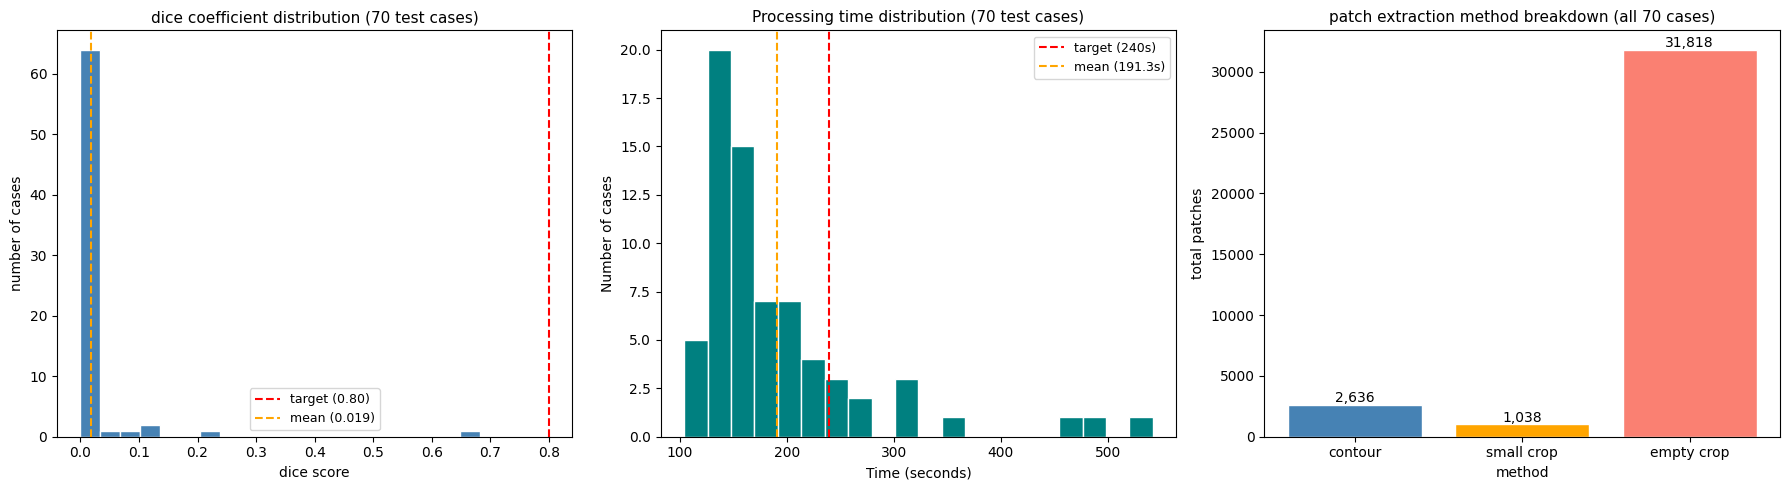

Saved: distributions.png


In [10]:
# distribution visualizations
# dice, processing time, patch method breakdown

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# dice distribution
axes[0].hist(pred_df['dice_3d'], bins = 20, color = 'steelblue', edgecolor = 'white')
axes[0].axvline(0.80, color = 'red', linestyle = '--', label = 'target (0.80)')
axes[0].axvline(pred_df['dice_3d'].mean(), color='orange',
                linestyle = '--', label = f'mean ({pred_df["dice_3d"].mean():.3f})')
axes[0].set_title('dice coefficient distribution (70 test cases)', fontsize = 11)
axes[0].set_xlabel('dice score')
axes[0].set_ylabel('number of cases')
axes[0].legend(fontsize = 9)

# processing time distribution
axes[1].hist(pred_df['processing_time_s'], bins = 20, color = 'teal', edgecolor = 'white')
axes[1].axvline(240, color = 'red', linestyle = '--', label = 'target (240s)')
axes[1].axvline(pred_df['processing_time_s'].mean(), color = 'orange',
                linestyle = '--', label=f'mean ({pred_df["processing_time_s"].mean():.1f}s)')
axes[1].set_title('Processing time distribution (70 test cases)', fontsize = 11)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Number of cases')
axes[1].legend(fontsize = 9)

# patch method breakdown
patch_methods = {
    'contour'   : pred_df['patches_contour'].sum(),
    'small crop': pred_df['patches_small'].sum(),
    'empty crop': pred_df['patches_empty'].sum(),
}
axes[2].bar(patch_methods.keys(), patch_methods.values(),
            color = ['steelblue', 'orange', 'salmon'], edgecolor = 'white')
axes[2].set_title('patch extraction method breakdown (all 70 cases)', fontsize = 11)
axes[2].set_xlabel('method')
axes[2].set_ylabel('total patches')
for i, (k, v) in enumerate(patch_methods.items()):
    axes[2].text(i, v + 200, f'{v:,}', ha='center', fontsize = 10)

plt.tight_layout()
plt.savefig(str(output_dir / 'distributions.png'), dpi = 150, bbox_inches = 'tight')
plt.show()
print('Saved: distributions.png')

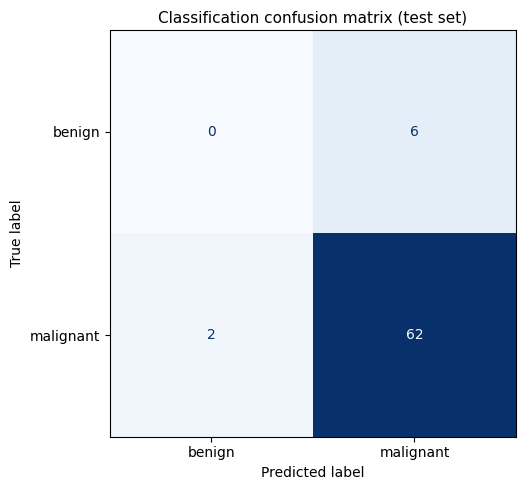

Saved: confusion_matrix.png


In [11]:
# Classification confusion matrix

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize = (6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix = cm,
                              display_labels = ['benign', 'malignant'])
disp.plot(ax = ax, colorbar = False, cmap = 'Blues')
ax.set_title('Classification confusion matrix (test set)', fontsize = 11)
plt.tight_layout()
plt.savefig(str(output_dir / 'confusion_matrix.png'), dpi = 150, bbox_inches = 'tight')
plt.show()
print('Saved: confusion_matrix.png')

In [16]:
# find the slice with most predicted pixels
slice_counts = [(i, (pred_mask[i] > 0.5).sum()) for i in range(pred_mask.shape[0])]
slice_counts.sort(key=lambda x: x[1], reverse=True)

print('top 5 slices by predicted pixel count:')
for i, count in slice_counts[:5]:
    print(f'  slice {i:04d}: {count} pixels')

print(f'\npred_mask value range: {pred_mask.min():.4f} to {pred_mask.max():.4f}')
print(f'pred_mask unique values sample: {np.unique(pred_mask[:5])[:10]}')

top 5 slices by predicted pixel count:
  slice 0336: 10072 pixels
  slice 0335: 10023 pixels
  slice 0337: 9516 pixels
  slice 0334: 9461 pixels
  slice 0352: 8445 pixels

pred_mask value range: 0.0000 to 1.0000
pred_mask unique values sample: [          0]


pred_mask shape : (512, 256, 256)


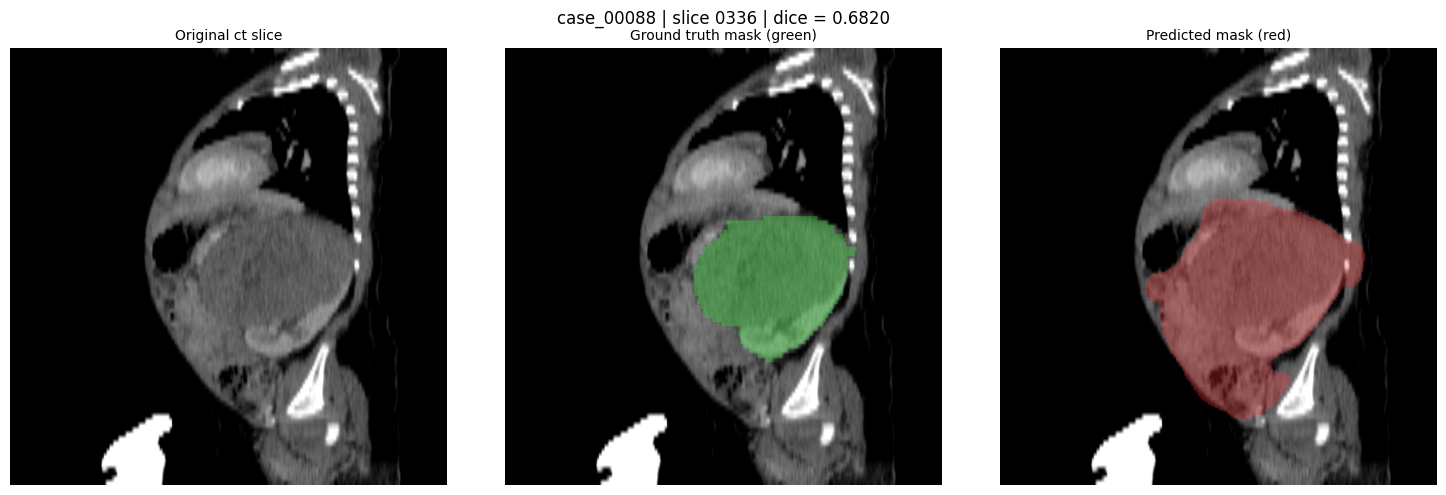

Saved: case_00088_segmentation_overlay.png


In [17]:
# Segmentation overlay for case_00088
# best segmentation result: dice 0.6820

import nibabel as nib

case_id   = 'case_00088'
slice_idx = 336
disp_size = 512

# load predicted mask - shape is (n_slices, 256, 256)
mask_path  = results_dir / f'phase9_pipeline/masks/{case_id}_pred_mask.nii.gz'
mask_nii   = nib.load(str(mask_path))
pred_mask  = mask_nii.get_fdata()
print(f'pred_mask shape : {pred_mask.shape}')

# extract slice and resize to display size
pred_slice = pred_mask[slice_idx]   # (256, 256)
pred_slice = cv2.resize(pred_slice.astype(np.float32),
                        (disp_size, disp_size),
                        interpolation=cv2.INTER_NEAREST)

# load and resize ct slice to display size
slice_path = slices_dir / f'test/{case_id}/images/slice_{slice_idx:04d}.png'
ct_slice   = np.array(Image.open(str(slice_path)).convert('RGB'))
ct_slice   = cv2.resize(ct_slice, (disp_size, disp_size),
                        interpolation=cv2.INTER_LINEAR)

# load and resize ground truth mask
gt_path   = slices_dir / f'test/{case_id}/masks/slice_{slice_idx:04d}.png'
gt_mask   = np.array(Image.open(str(gt_path)))
gt_mask   = cv2.resize(gt_mask, (disp_size, disp_size),
                       interpolation=cv2.INTER_NEAREST)
gt_binary = (gt_mask > 0).astype(np.uint8)

# predicted overlay in red
overlay_pred              = ct_slice.copy()
mask_bool                 = pred_slice > 0.5
overlay_pred[mask_bool]   = [255, 50, 50]
blended_pred              = cv2.addWeighted(ct_slice, 0.7, overlay_pred, 0.3, 0)

# ground truth overlay in green
overlay_gt               = ct_slice.copy()
overlay_gt[gt_binary > 0] = [50, 255, 50]
blended_gt               = cv2.addWeighted(ct_slice, 0.7, overlay_gt, 0.3, 0)

# plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ct_slice)
axes[0].set_title('Original ct slice', fontsize = 10)
axes[0].axis('off')

axes[1].imshow(blended_gt)
axes[1].set_title('Ground truth mask (green)', fontsize = 10)
axes[1].axis('off')

axes[2].imshow(blended_pred)
axes[2].set_title('Predicted mask (red)', fontsize = 10)
axes[2].axis('off')

fig.suptitle(f'{case_id} | slice {slice_idx:04d} | dice = 0.6820', fontsize = 12)
plt.tight_layout()
plt.savefig(str(output_dir / f'{case_id}_segmentation_overlay.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {case_id}_segmentation_overlay.png')

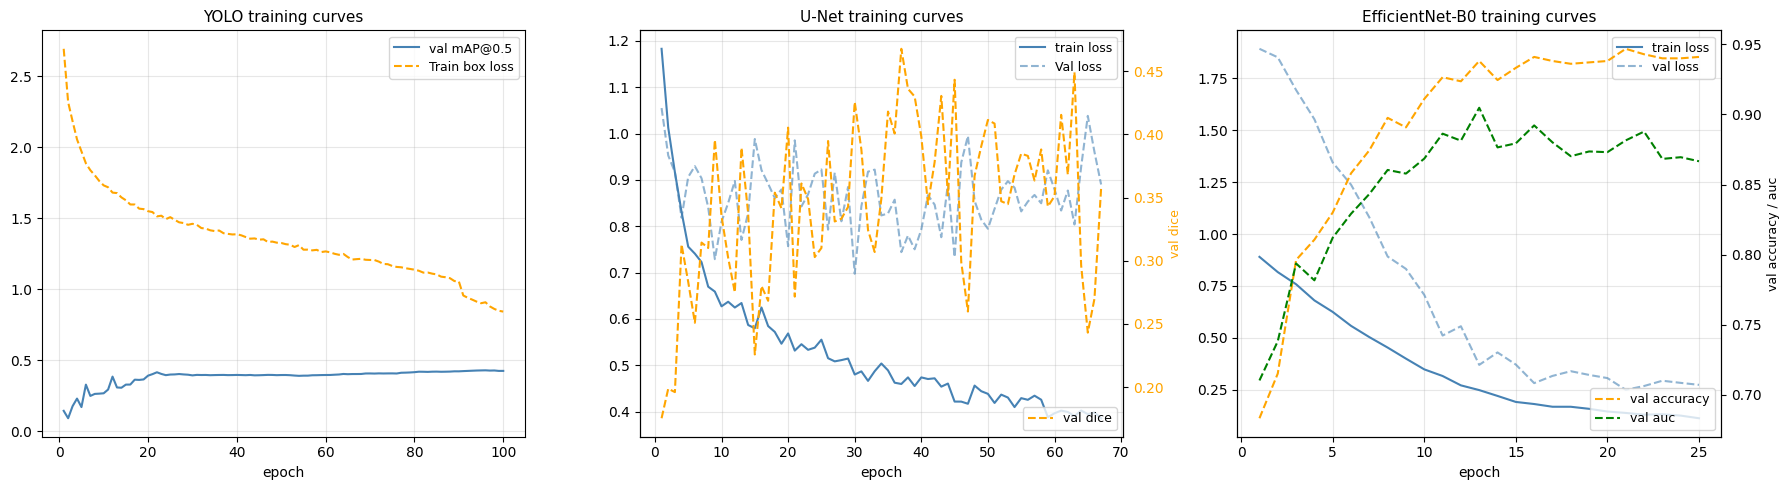

Saved: training_curves.png


In [28]:
# Training curves for all three models

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# YOLO
yolo_csv = results_dir / 'phase5_yolo_retrain/yolov8s_retrain_run1/results.csv'
yolo_df  = pd.read_csv(yolo_csv)
yolo_df.columns = yolo_df.columns.str.strip()

axes[0].plot(yolo_df['epoch'], yolo_df['metrics/mAP50(B)'],
             label = 'val mAP@0.5', color = 'steelblue')
axes[0].plot(yolo_df['epoch'], yolo_df['train/box_loss'],
             label = 'Train box loss', color = 'orange', linestyle = '--')
axes[0].set_title('YOLO training curves', fontsize = 11)
axes[0].set_xlabel('epoch')
axes[0].legend(fontsize = 9)
axes[0].grid(alpha = 0.3)

# U-Net
unet_df = pd.read_csv(results_dir / 'phase6_unet/metrics.csv')

axes[1].plot(unet_df['epoch'], unet_df['train_loss'],
             label = 'train loss', color = 'steelblue')
axes[1].plot(unet_df['epoch'], unet_df['val_loss'],
             label = 'Val loss', color = 'steelblue', linestyle = '--', alpha = 0.6)
ax2 = axes[1].twinx()
ax2.plot(unet_df['epoch'], unet_df['val_dice'],
         label = 'val dice', color = 'orange', linestyle = '--')
ax2.set_ylabel('val dice', color = 'orange', fontsize = 9)
ax2.tick_params(axis='y', labelcolor='orange')
ax2.legend(loc='lower right', fontsize = 9)
axes[1].set_title('U-Net training curves', fontsize = 11)
axes[1].set_xlabel('epoch')
axes[1].legend(loc='upper right', fontsize = 9)
axes[1].grid(alpha = 0.3)

# EfficientNet
eff_df = pd.read_csv(results_dir / 'phase7_efficientnet/metrics/training_log.csv')

axes[2].plot(eff_df['epoch'], eff_df['train_loss'],
             label = 'train loss', color = 'steelblue')
axes[2].plot(eff_df['epoch'], eff_df['val_loss'],
             label = 'val loss', color = 'steelblue', linestyle = '--', alpha = 0.6)
ax3 = axes[2].twinx()
ax3.plot(eff_df['epoch'], eff_df['val_acc'],
         label = 'val accuracy', color = 'orange', linestyle = '--')
ax3.plot(eff_df['epoch'], eff_df['val_auc'],
         label = 'val auc', color = 'green', linestyle = '--')
ax3.set_ylabel('val accuracy / auc', fontsize = 9)
ax3.legend(loc='lower right', fontsize = 9)
axes[2].set_title('EfficientNet-B0 training curves', fontsize = 11)
axes[2].set_xlabel('epoch')
axes[2].legend(loc='upper right', fontsize = 9)
axes[2].grid(alpha = 0.3)

plt.tight_layout()
plt.savefig(str(output_dir / 'training_curves.png'), dpi = 150, bbox_inches = 'tight')
plt.show()
print('Saved: training_curves.png')

In [29]:
# Final Summary

print('Phase 10 Evaluation Summary')

print('\nDetection (YOLO)')
print(f'  Precision      : {yolo_metrics["precision"]:.4f}')
print(f'  Recall         : {yolo_metrics["recall"]:.4f}')
print(f'  mAP@0.5        : {yolo_metrics["map_50"]:.4f}')
print(f'  mAP@0.50:0.95  : {yolo_metrics["map_50_95"]:.4f}')
print(f'  Case detection : {yolo_metrics["cases_with_detection"]}/{yolo_metrics["total_test_cases"]}')

print('\nSegmentation (U-Net) ---')
print(f'  Mean dice      : {seg_metrics["mean_dice"]:.4f}  (target >= 0.80)')
print(f'  Median dice    : {seg_metrics["median_dice"]:.4f}')
print(f'  Max dice       : {seg_metrics["max_dice"]:.4f}  (case_00088)')
print(f'  Mean iou       : {seg_metrics["mean_iou"]:.4f}  (target >= 0.75)')
print(f'  Cases dice = 0   : {seg_metrics["cases_dice_zero"]}')

print('\nClassification (EfficientNet)')
print(f'  Accuracy       : {cls_metrics["accuracy"]:.4f}  (target > 0.85)')
print(f'  Sensitivity    : {cls_metrics["sensitivity"]:.4f}  (target > 0.90)')
print(f'  Specificity    : {cls_metrics["specificity"]:.4f}')
print(f'  F1 score       : {cls_metrics["f1_score"]:.4f}')
print(f'  AUC            : {cls_metrics["auc"]:.4f}')

print('\nProcessing time')
print(f'  Mean time      : {time_metrics["mean_time_s"]:.1f}s  (target < 120s)')
print(f'  Cases < 240s   : {time_metrics["cases_under_240s"]}/70')
print(f'  Target met     : {time_metrics["target_met_pct"]}%')

print('\nOutputs saved')
for f in sorted(output_dir.glob('*')):
    print(f'  {f.name}')

print('Phase 10 complete')


Phase 10 Evaluation Summary

Detection (YOLO)
  Precision      : 0.6426
  Recall         : 0.5060
  mAP@0.5        : 0.5340
  mAP@0.50:0.95  : 0.2405
  Case detection : 68/70

Segmentation (U-Net) ---
  Mean dice      : 0.0189  (target >= 0.80)
  Median dice    : 0.0000
  Max dice       : 0.6820  (case_00088)
  Mean iou       : 0.0123  (target >= 0.75)
  Cases dice = 0   : 58

Classification (EfficientNet)
  Accuracy       : 0.8857  (target > 0.85)
  Sensitivity    : 0.9688  (target > 0.90)
  Specificity    : 0.0000
  F1 score       : 0.9394
  AUC            : 0.5768

Processing time
  Mean time      : 191.3s  (target < 120s)
  Cases < 240s   : 59/70
  Target met     : 84.29%

Outputs saved
  case_00088_segmentation_overlay.png
  classification_metrics.csv
  confusion_matrix.png
  distributions.png
  processing_time_metrics.csv
  segmentation_metrics.csv
  training_curves.png
  yolo_metrics.csv
Phase 10 complete
